In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6"> 05_XOR를 tensorflow v2로</font></b>

# 1. 

#### 텐서1->텐서2

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [2]:
# 1. XOR 데이터
X_data = np.array([[0,0],
                   [0,1],
                   [1,0],
                   [1,1]], dtype=np.float32)

y_data = np.array([[0],
                   [1],
                   [1],
                   [0]], dtype=np.float32)

# 2. 모델 구성
model = Sequential([
    Dense(10, input_shape=(2,), activation='relu'),  # layer1: 2 -> 10
    Dense(20, activation='relu'),                    # layer2: 10 -> 20
    Dense(10, activation='relu'),                    # layer3: 20 -> 10
    Dense(1, activation='sigmoid')                   # layer4: 10 -> 1
])

# 3. 컴파일 (손실함수, 최적화, 평가지표 설정)
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. 학습
model.fit(X_data, y_data, epochs=1000, verbose=0)

# 5. 예측 결과 확인
predictions = model.predict(X_data)
print("\n예측 결과:")
for i, pred in enumerate(predictions):
    print(f"{X_data[i]} => {pred[0]:.4f} (분류: {int(pred[0] > 0.5)})")


1/1 [==============================] - 0s 150ms/step

예측 결과:
[0. 0.] => 0.3249 (분류: 0)
[0. 1.] => 0.5051 (분류: 1)
[1. 0.] => 0.8387 (분류: 1)
[1. 1.] => 0.2449 (분류: 0)


In [4]:
loss, acc = model.evaluate(X_data, y_data, verbose=0)
print(f"모델 정확도 : {acc:.4f}")

모델 정확도 : 1.0000


In [5]:
# 예측값
predictions = model.predict(X_data)
# 0.5 기준으로 이진 분류
predicted_classes = (predictions >= 0.5).astype(np.float32)

# 정확도 계산
accuracy = np.mean(predicted_classes == y_data)
print(f"모델 정확도 : {accuracy:.4f}")


1/1 [==============================] - 0s 30ms/step
모델 정확도 : 1.0000


#### 텐서1->텐서2 선생님 ver

In [19]:
import numpy as np
from tensorflow.keras.models import Sequential # 모델 객체 생성
from tensorflow.keras.layers import Input, Dense # layer 층을 쌓을 때 필요

In [20]:
# 1. data set
# 2. data 전처리
X_data = np.array([[0,0],
                   [0,1],
                   [1,0],
                   [1,1]],)

y_data = np.array([[0],
                   [1],
                   [1],
                   [0]],)

In [21]:
# 3. 모델 구성
# layer 층 x_data 2개 -> 10 -> 20 -> 10 -> 1
model = Sequential()
# model.add(Input(shape=(2,))) # 입력층
model.add(Dense(units=10, # 출력
                input_dim=2, # 입력층
                activation='relu')) # 활성화 함수
model.add(Dense(units=20, activation='relu'))
model.add(Dense(units=10, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) 
# 이진분류에서의 출력층 활성화 함수 sigmoid
# 다중분류에서의 출력층 활성화 함수 softmax(출력합을 1로)
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 10)                30        
                                                                 
 dense_13 (Dense)            (None, 20)                220       
                                                                 
 dense_14 (Dense)            (None, 10)                210       
                                                                 
 dense_15 (Dense)            (None, 1)                 11        
                                                                 
Total params: 471
Trainable params: 471
Non-trainable params: 0
_________________________________________________________________


In [22]:
# 4. 모델 학습과정 설정
model.compile(loss='binary_crossentropy', # 다중분류면 그냥 크로스엔트로피
              optimizer='adam',
              metrics=['binary_accuracy']) # 2진분류 

In [23]:
# 5. 학습
hist = model.fit(X_data, # 훈련데이터
          y_data, 
          epochs=600, # 학습 횟수
#           batch_size=2,
          verbose=2) # 학습 로그 출력, 0=출력안됨, 1=보통, 2=상세출력

Epoch 1/600
1/1 - 0s - loss: 0.7161 - binary_accuracy: 0.7500 - 433ms/epoch - 433ms/step
Epoch 2/600
1/1 - 0s - loss: 0.7129 - binary_accuracy: 0.5000 - 5ms/epoch - 5ms/step
Epoch 3/600
1/1 - 0s - loss: 0.7103 - binary_accuracy: 0.5000 - 5ms/epoch - 5ms/step
Epoch 4/600
1/1 - 0s - loss: 0.7086 - binary_accuracy: 0.5000 - 3ms/epoch - 3ms/step
Epoch 5/600
1/1 - 0s - loss: 0.7064 - binary_accuracy: 0.7500 - 4ms/epoch - 4ms/step
Epoch 6/600
1/1 - 0s - loss: 0.7040 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 7/600
1/1 - 0s - loss: 0.7016 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 8/600
1/1 - 0s - loss: 0.6991 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 9/600
1/1 - 0s - loss: 0.6967 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 10/600
1/1 - 0s - loss: 0.6947 - binary_accuracy: 0.7500 - 5ms/epoch - 5ms/step
Epoch 11/600
1/1 - 0s - loss: 0.6925 - binary_accuracy: 0.7500 - 5ms/epoch - 5ms/step
Epoch 12/600
1/1 - 0s - loss: 0.6902 - binary_accuracy: 0.7

Epoch 97/600
1/1 - 0s - loss: 0.5728 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 98/600
1/1 - 0s - loss: 0.5708 - binary_accuracy: 0.7500 - 5ms/epoch - 5ms/step
Epoch 99/600
1/1 - 0s - loss: 0.5690 - binary_accuracy: 0.7500 - 5ms/epoch - 5ms/step
Epoch 100/600
1/1 - 0s - loss: 0.5673 - binary_accuracy: 0.7500 - 5ms/epoch - 5ms/step
Epoch 101/600
1/1 - 0s - loss: 0.5653 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 102/600
1/1 - 0s - loss: 0.5634 - binary_accuracy: 0.7500 - 3ms/epoch - 3ms/step
Epoch 103/600
1/1 - 0s - loss: 0.5614 - binary_accuracy: 0.7500 - 4ms/epoch - 4ms/step
Epoch 104/600
1/1 - 0s - loss: 0.5594 - binary_accuracy: 0.7500 - 4ms/epoch - 4ms/step
Epoch 105/600
1/1 - 0s - loss: 0.5573 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 106/600
1/1 - 0s - loss: 0.5552 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 107/600
1/1 - 0s - loss: 0.5531 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 108/600
1/1 - 0s - loss: 0.5511 - binary

Epoch 192/600
1/1 - 0s - loss: 0.3678 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 193/600
1/1 - 0s - loss: 0.3663 - binary_accuracy: 1.0000 - 5ms/epoch - 5ms/step
Epoch 194/600
1/1 - 0s - loss: 0.3645 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 195/600
1/1 - 0s - loss: 0.3629 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 196/600
1/1 - 0s - loss: 0.3615 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 197/600
1/1 - 0s - loss: 0.3598 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 198/600
1/1 - 0s - loss: 0.3581 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 199/600
1/1 - 0s - loss: 0.3565 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 200/600
1/1 - 0s - loss: 0.3550 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 201/600
1/1 - 0s - loss: 0.3536 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 202/600
1/1 - 0s - loss: 0.3521 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 203/600
1/1 - 0s - loss: 0.3504 - bin

Epoch 287/600
1/1 - 0s - loss: 0.2752 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 288/600
1/1 - 0s - loss: 0.2747 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 289/600
1/1 - 0s - loss: 0.2741 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 290/600
1/1 - 0s - loss: 0.2735 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 291/600
1/1 - 0s - loss: 0.2730 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 292/600
1/1 - 0s - loss: 0.2724 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 293/600
1/1 - 0s - loss: 0.2720 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 294/600
1/1 - 0s - loss: 0.2714 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 295/600
1/1 - 0s - loss: 0.2710 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 296/600
1/1 - 0s - loss: 0.2705 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 297/600
1/1 - 0s - loss: 0.2700 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 298/600
1/1 - 0s - loss: 0.2695 - bin

Epoch 382/600
1/1 - 0s - loss: 0.1265 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 383/600
1/1 - 0s - loss: 0.1250 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 384/600
1/1 - 0s - loss: 0.1235 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 385/600
1/1 - 0s - loss: 0.1220 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 386/600
1/1 - 0s - loss: 0.1205 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 387/600
1/1 - 0s - loss: 0.1191 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 388/600
1/1 - 0s - loss: 0.1177 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 389/600
1/1 - 0s - loss: 0.1162 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 390/600
1/1 - 0s - loss: 0.1149 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 391/600
1/1 - 0s - loss: 0.1135 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 392/600
1/1 - 0s - loss: 0.1122 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 393/600
1/1 - 0s - loss: 0.1109 - bin

Epoch 477/600
1/1 - 0s - loss: 0.0476 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 478/600
1/1 - 0s - loss: 0.0472 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 479/600
1/1 - 0s - loss: 0.0468 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 480/600
1/1 - 0s - loss: 0.0464 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 481/600
1/1 - 0s - loss: 0.0460 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 482/600
1/1 - 0s - loss: 0.0456 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 483/600
1/1 - 0s - loss: 0.0452 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 484/600
1/1 - 0s - loss: 0.0448 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 485/600
1/1 - 0s - loss: 0.0444 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 486/600
1/1 - 0s - loss: 0.0441 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 487/600
1/1 - 0s - loss: 0.0437 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 488/600
1/1 - 0s - loss: 0.0433 - bin

1/1 - 0s - loss: 0.0225 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 572/600
1/1 - 0s - loss: 0.0224 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 573/600
1/1 - 0s - loss: 0.0222 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 574/600
1/1 - 0s - loss: 0.0220 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 575/600
1/1 - 0s - loss: 0.0219 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 576/600
1/1 - 0s - loss: 0.0217 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 577/600
1/1 - 0s - loss: 0.0216 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 578/600
1/1 - 0s - loss: 0.0214 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 579/600
1/1 - 0s - loss: 0.0213 - binary_accuracy: 1.0000 - 3ms/epoch - 3ms/step
Epoch 580/600
1/1 - 0s - loss: 0.0211 - binary_accuracy: 1.0000 - 5ms/epoch - 5ms/step
Epoch 581/600
1/1 - 0s - loss: 0.0210 - binary_accuracy: 1.0000 - 4ms/epoch - 4ms/step
Epoch 582/600
1/1 - 0s - loss: 0.0208 - binary_accuracy: 

In [24]:
# 6. 학습 과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'binary_accuracy'])

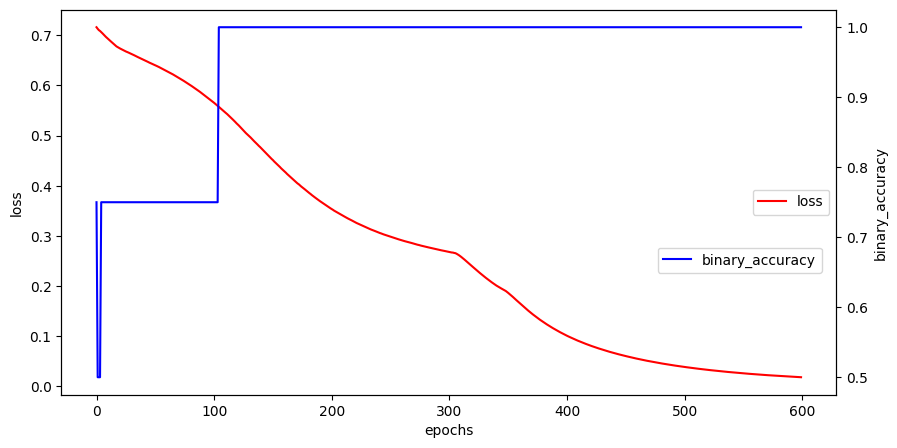

In [25]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'r', label='loss')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='center right')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['binary_accuracy'], 'b', label='binary_accuracy')
acc_ax.set_ylabel('binary_accuracy')
acc_ax.legend(bbox_to_anchor=(0.99, 0.4))

In [26]:
# 7. 학습 평가하기
score = model.evaluate(X_data, y_data,
#                        batch_size=,
                      )
print('loss : ', score[0])
print('binary accuracy : ', score[1])

1/1 [==============================] - 0s 137ms/step - loss: 0.0182 - binary_accuracy: 1.0000
loss :  0.01822790876030922
binary accuracy :  1.0


#### save 및 모델 사용 predict

In [28]:
# 8. 모델 사용
model.predict(np.array([[0, 1]])).round()

1/1 [==============================] - 0s 24ms/step


array([[1.]], dtype=float32)

In [29]:
model.predict(np.array([[0, 1],
                        [1, 1]])).round()

1/1 [==============================] - 0s 25ms/step


array([[1.],
       [0.]], dtype=float32)